<div align = "right">
12 / 05 / 26
<div style = "height: 20px;"></div>
<span style = "color:orange"> <strong>Reconocimiento de Patrones </strong></span>
<style>div[align = "right"]{font-family: 'Montserrat', sans-serif;}</style></div>

<h1 style = "color: orange"><strong> Práctica 4: Clasificadores (cancer)</strong></h1>

In [36]:
# Bibliotecas
import os
import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from PIL import Image
from matplotlib.lines import Line2D
from imblearn.over_sampling import SMOTE
from ydata_profiling import ProfileReport
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder
from IPython.display import HTML, Video, display

from sklearn.svm import SVC
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

In [37]:
RUTA_IMG = '/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img'
RUTA_SANBORNS = '/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Auxiliares/sanborns.png'
AZUL_TELCEL = '#0B4DA2'
ROJO_TECOLOTE = '#DA291C'

os.makedirs(RUTA_IMG, exist_ok = True)

def guardar_figura(nombre):
    """Guarda la figura activa en RUTA_IMG con el nombre dado (.png)."""
    ruta = os.path.join(RUTA_IMG, nombre)
    plt.savefig(ruta, dpi = 300, bbox_inches = 'tight')
    print(f'{ruta}')

## 1. Cargar y análisis de los datos

### 1a) Carga del con conjunto de datos de cancer 

In [38]:
# Datos

# Cancer
cancer = './data/wdbc.data'

columnas_cat = (['id', 'diagnosis'])
columnas_mean = (['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean',
    'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean'])

columnas_se = (['radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 
                'concave_points_se', 'symmetry_se', 'fractal_dimension_se'])

columnas_worst = (['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 
                   'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'])

columnas_cancer = (columnas_cat +columnas_mean + columnas_se + columnas_worst)

df_cancer = pd.read_csv(cancer, header = None, names = columnas_cancer, na_values = '?')
df_cancer.sample(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
437,909220,B,14.04,15.98,89.78,611.2,0.08458,0.05895,0.03534,0.02944,...,15.66,21.58,101.20,750.0,0.1195,0.1252,0.11170,0.07453,0.2725,0.07234
257,886776,M,15.32,17.27,103.20,713.3,0.13350,0.22840,0.24480,0.12420,...,17.73,22.66,119.80,928.8,0.1765,0.4503,0.44290,0.22290,0.3258,0.11910
345,898677,B,10.26,14.71,66.20,321.6,0.09882,0.09159,0.03581,0.02037,...,10.88,19.48,70.89,357.1,0.1360,0.1636,0.07162,0.04074,0.2434,0.08488
487,913505,M,19.44,18.82,128.10,1167.0,0.10890,0.14480,0.22560,0.11940,...,23.96,30.39,153.90,1740.0,0.1514,0.3725,0.59360,0.20600,0.3266,0.09009
162,871201,M,19.59,18.15,130.70,1214.0,0.11200,0.16660,0.25080,0.12860,...,26.73,26.39,174.90,2232.0,0.1438,0.3846,0.68100,0.22470,0.3643,0.09223


### 1b-c) Visualización de distribución de clases y análisis de valores faltantes

Solo se toma una parte de las columnas para optimizar el tiempo de creación del reporte.

In [39]:
Reporte_cancer = ProfileReport(df_cancer[columnas_mean], title = 'Reporte de Cancer', explorative = True)
# Reporte_cancer.to_notebook_iframe()

In [40]:
Reporte_cancer.to_file('Reporte_cancer.html')

/home/ibra/venv_ds/lib/python3.10/site-packages/ydata_profiling/utils/dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 944.13it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [41]:
faltantes_c = df_cancer.isnull().sum()
faltantes_cancer = (faltantes_c / len(df_cancer)) * 100
print("Valores faltantes por columna (%):\n")

for i in range(len(faltantes_cancer)):
    
    if faltantes_cancer.iloc[i] > 0.0:
    
        print(faltantes_cancer.iloc[i])

Valores faltantes por columna (%):



## 2. Preprocesamiento y limpieza

### 2b) Separación de columnas categóricas y numéricas

In [42]:
columnas_cat = df_cancer.select_dtypes(include = ['object']).columns
columnas_num = df_cancer.select_dtypes(include = ['number']).columns
columnas_num = columnas_num.drop('id')
columnas_cat = columnas_cat.insert(0, 'id')

cat_html = ' '.join(f'<span style="color:{AZUL_TELCEL};font-weight:600;margin-right:8px">{c}</span>' for c in columnas_cat)
num_html = ' '.join(f'<span style="color:{ROJO_TECOLOTE};margin-right:8px">{c}</span>' for c in columnas_num)

display(HTML(f"<div><strong>Columnas categóricas:</strong> {cat_html}</div><div style='margin-top:8px'><strong>Columnas numéricas:</strong> {num_html}</div>"))

*Nota: en este caso, `id` es una columna categórica (aunque sea de tipo numérica), pues identifica a cada muestra de forma única.*

Ya que tenemos las características separadas, se preprocesarán para eventualmente estandarizar los datos y aplicar los modelos de clasificación. 

### 2b) Faltantes, outliers, caracteres inválidos

El análisis previo no mostró datos faltantes, lo cual se celebra.

In [43]:
HTML("""
<div style="display:flex; justify-content:center;">
    <video width="300"
           height="300"
           autoplay
           loop
           muted
           playsinline>
        <source src="./Auxiliares/peyos.mp4" type="video/mp4">
    </video>
</div>
""")

Para los outliers, los detectaremos usando el método intercuartílico IQR.

In [44]:
# IQR 
Q1 = df_cancer[columnas_num].quantile(0.25)
Q3 = df_cancer[columnas_num].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df_cancer[columnas_num] < lower_bound) | (df_cancer[columnas_num] > upper_bound)
n_outliers = outlier_mask.sum().sort_values(ascending = False)
resumen_iqr = pd.DataFrame({
    'outliers': n_outliers,
    'porcentaje' : (n_outliers / len(df_cancer) * 100).round(1)
})

print('Outliers por columna (IQR):')
display(resumen_iqr[resumen_iqr['outliers'] > 0])
print(f"\nFilas con más de un outlier: {outlier_mask.any(axis = 1).sum()} / {len(df_cancer)}")

Outliers por columna (IQR):


,outliers,porcentaje
area_se,65,11.4
radius_se,38,6.7
perimeter_se,38,6.7
area_worst,35,6.2
smoothness_se,30,5.3
fractal_dimension_se,28,4.9
compactness_se,28,4.9
symmetry_se,27,4.7
area_mean,25,4.4
fractal_dimension_worst,24,4.2



Filas con más de un outlier: 171 / 569


/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/01_boxplot_cancer_Características_Medias.png


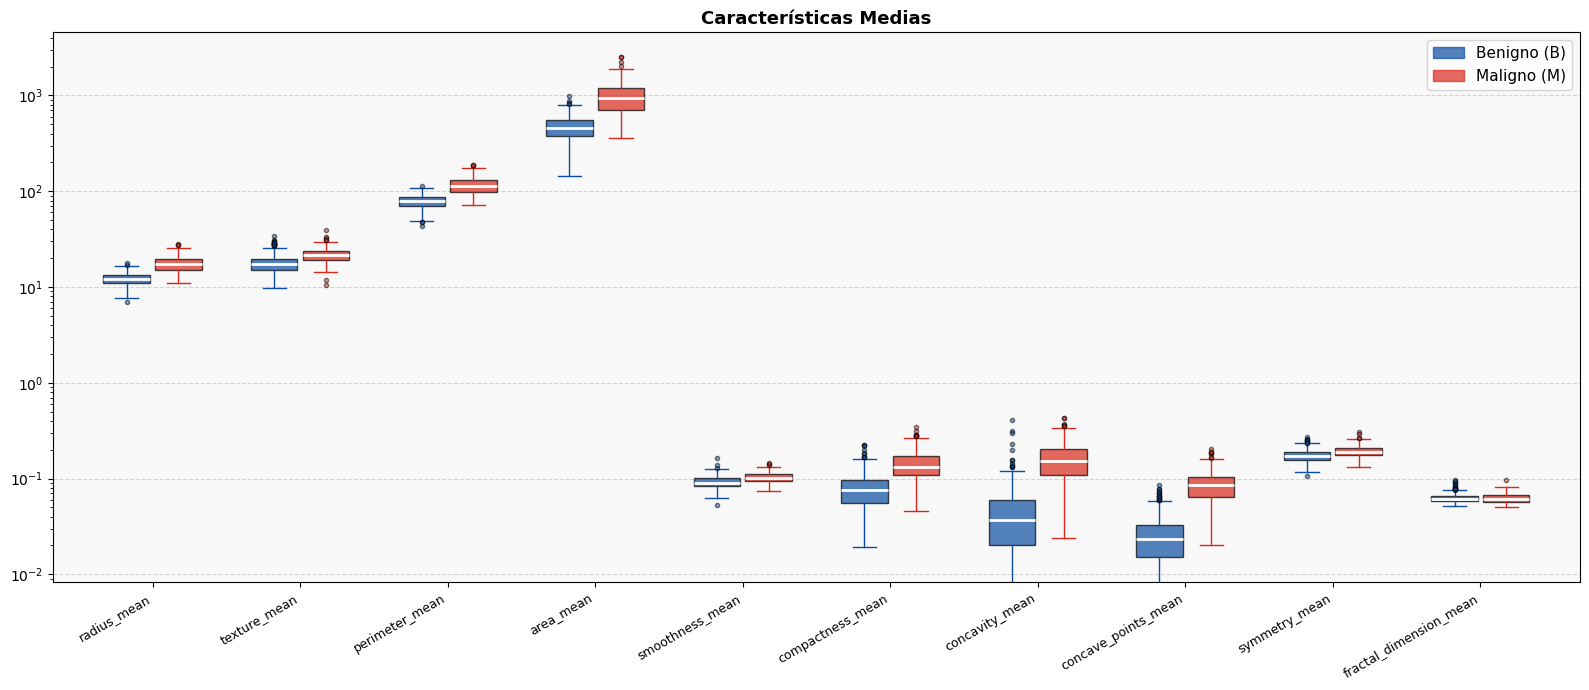

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/01_boxplot_cancer_Error_Estándar.png


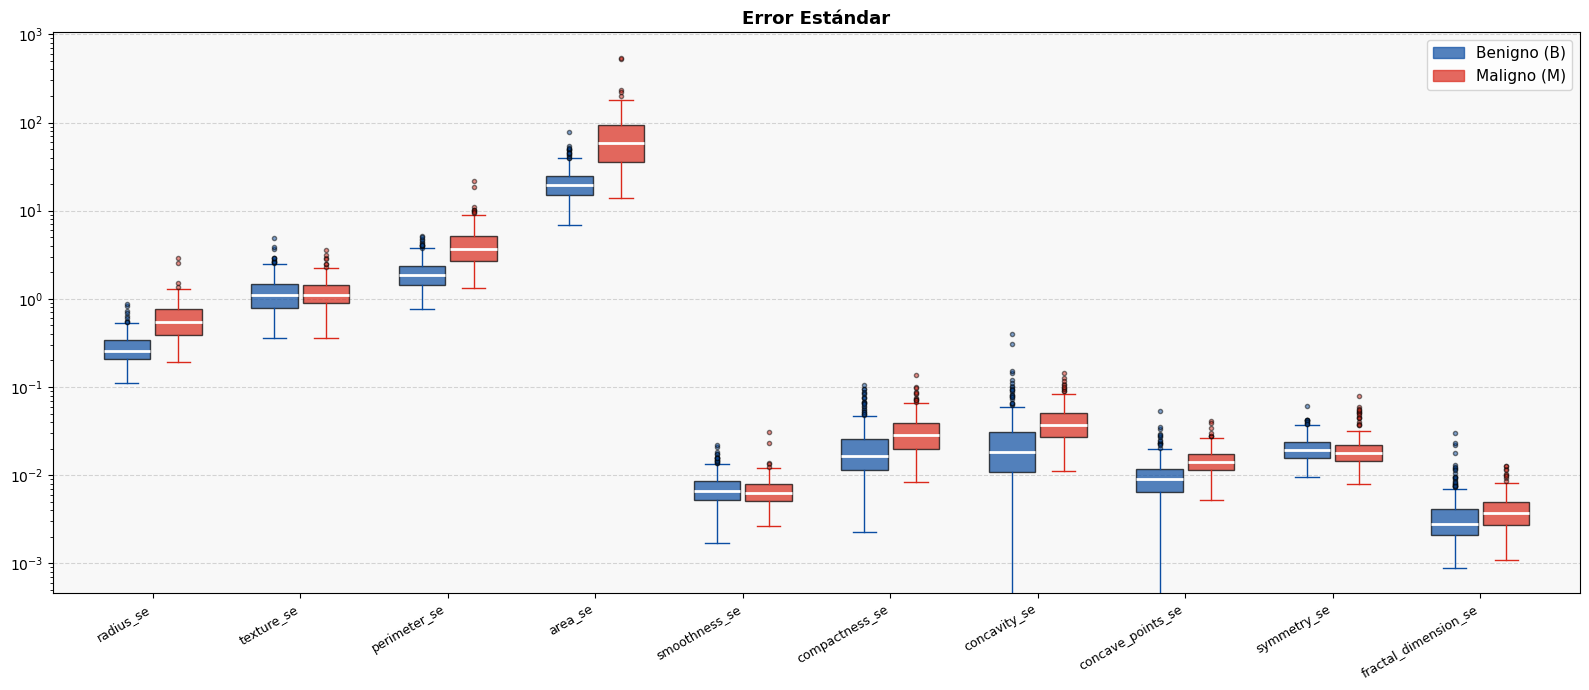

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/01_boxplot_cancer_Valores_Extremos.png


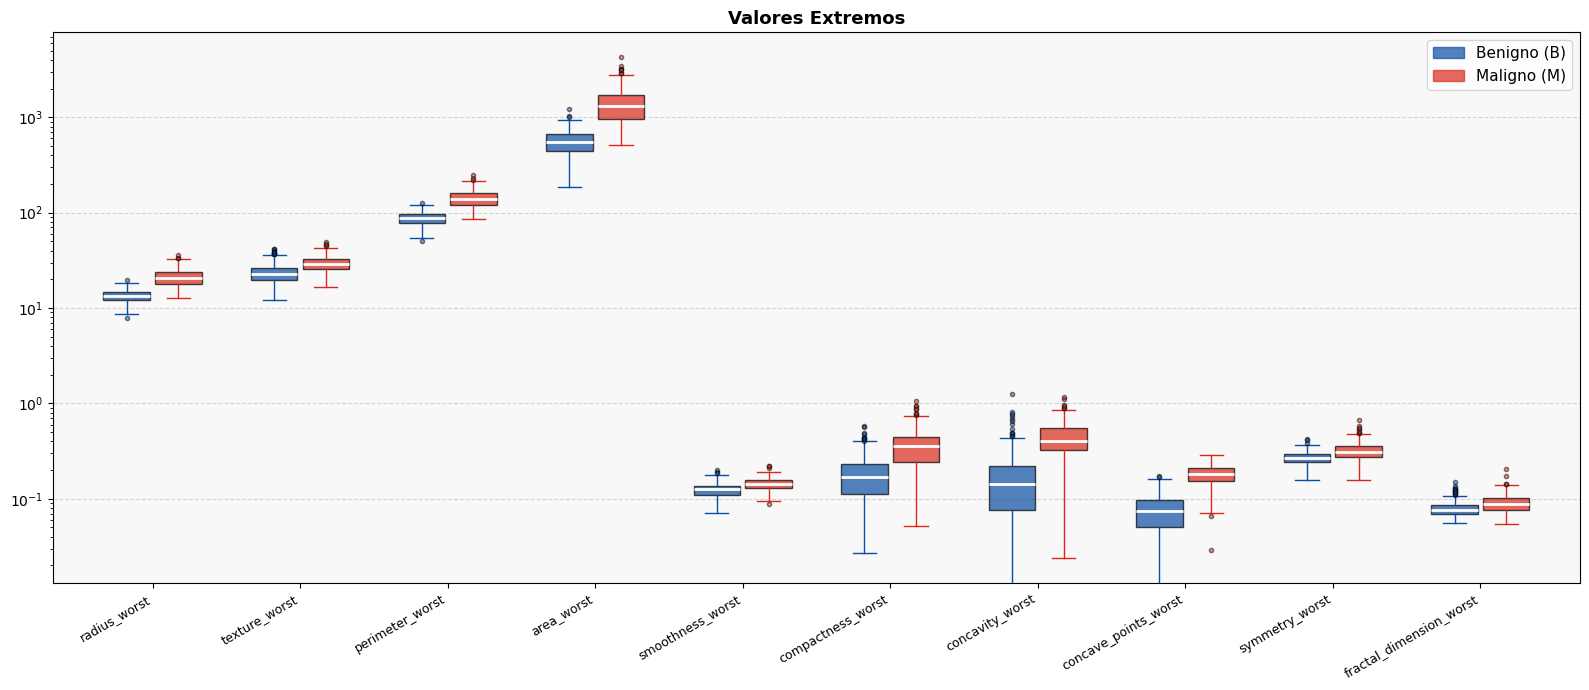

In [45]:
# Boxplots por grupos de características
grupos = [columnas_mean, columnas_se, columnas_worst]

titulos = ['Características Medias', 'Error Estándar', 'Valores Extremos']

for feats, titulo in zip(grupos, titulos):

    fig, ax = plt.subplots(figsize=(16, 7))

    data_B = [df_cancer.loc[df_cancer['diagnosis'] == 'B', f].values for f in feats]

    data_M = [df_cancer.loc[df_cancer['diagnosis'] == 'M', f].values for f in feats]

    x = np.arange(len(feats))
    w = 0.35

    kw_B = dict(patch_artist = True, boxprops = dict(facecolor = AZUL_TELCEL, alpha = 0.7),
        medianprops = dict(color = 'white', linewidth = 2),
        flierprops = dict(marker = 'o', markerfacecolor=AZUL_TELCEL, markersize = 3, alpha = 0.5),
        whiskerprops=dict(color = AZUL_TELCEL),
        capprops=dict(color = AZUL_TELCEL))

    kw_M = dict(patch_artist=True, boxprops=dict(facecolor=ROJO_TECOLOTE, alpha=0.7),
        medianprops=dict(color='white', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor=ROJO_TECOLOTE, markersize=3, alpha=0.5),
        whiskerprops=dict(color=ROJO_TECOLOTE), capprops=dict(color=ROJO_TECOLOTE))

    ax.boxplot(data_B, positions=x - w/2, widths=w * 0.9, **kw_B)
    ax.boxplot(data_M, positions=x + w/2, widths=w * 0.9, **kw_M)
    ax.set_xticks(x)
    ax.set_xticklabels(feats, rotation=30, ha='right', fontsize=9)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_facecolor('#f8f8f8')
    ax.set_yscale('log', base = 10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    handles = [mpatches.Patch( color=AZUL_TELCEL, alpha=0.7, label='Benigno (B)'),
        mpatches.Patch(color=ROJO_TECOLOTE, alpha=0.7, label='Maligno (M)')]

    ax.legend(handles=handles, fontsize=11)
    guardar_figura(f'01_boxplot_cancer_{titulo.replace(" ", "_")}.png')

    plt.tight_layout()
    plt.show()

### 2c) Estandarización de características

Tomamos nuestras características numéricas.

In [46]:
Stdsc = StandardScaler()
cancer_scaled = Stdsc.fit_transform(df_cancer[columnas_num])

### 2d) Separación de datos de entrenamiento y prueba


Ya con nuestra característica `y = diagnosis`, podemos separar los datos con el `train_test_split`. 

In [47]:
X, y = cancer_scaled, df_cancer['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.3, 
                                                    random_state = 43,
                                                    shuffle = True,
                                                    stratify = y)

In [48]:
X_train.shape, y_train.shape

((398, 30), (398,))

### 2e) Manejo de desbalance de clases


Primero se calcula el `ratio` de diagnosis:

In [49]:
# ratio de diagnosis
benigno = df_cancer['diagnosis'] == 'B'
maligno = df_cancer['diagnosis'] == 'M'

if maligno.sum() == 0 or benigno.sum() == 0:

    ratio = 0
    print('No hay casos para calcular el ratio.')

if maligno.sum() >= 0 and benigno.sum() > 0:

    ratio = maligno.sum() / benigno.sum()   

else:

    ratio = benigno.sum() / maligno.sum()

print(f'Casos de diagnosis malignos: {maligno.sum()}')
print(f'Casos de diagnosis benignos: {benigno.sum()}')
print(f'\nRatio: {ratio:.2f}')

Casos de diagnosis malignos: 212
Casos de diagnosis benignos: 357

Ratio: 0.59


En mi opinión, las clases de diagnosis no se encuentran tan desbalanceadas, así que no se debería tomar medidas para el desbalanceo. Pero igualmente voy a aplicar `SMOTE`.

In [50]:
# Sobremuestreo con SMOTE sobre el conjunto de entrenamiento
smote = SMOTE(random_state = 43)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Conteos
antes = pd.Series(y_train).value_counts()
despues = pd.Series(y_train_smote).value_counts()

print(f'Entrenamiento antes:\nB: {antes["B"]:>3}\nM: {antes["M"]:>3}\ntotal: {len(y_train)}')
print(f'\nEntrenamiento después:\nB: {despues["B"]:>3}\nM: {despues["M"]:>3}\ntotal: {len(y_train_smote)}')

Entrenamiento antes:
B: 250
M: 148
total: 398

Entrenamiento después:
B: 250
M: 250
total: 500


### 2f) Visualización de distribución


/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/02_distribucion_smote_cancer.png


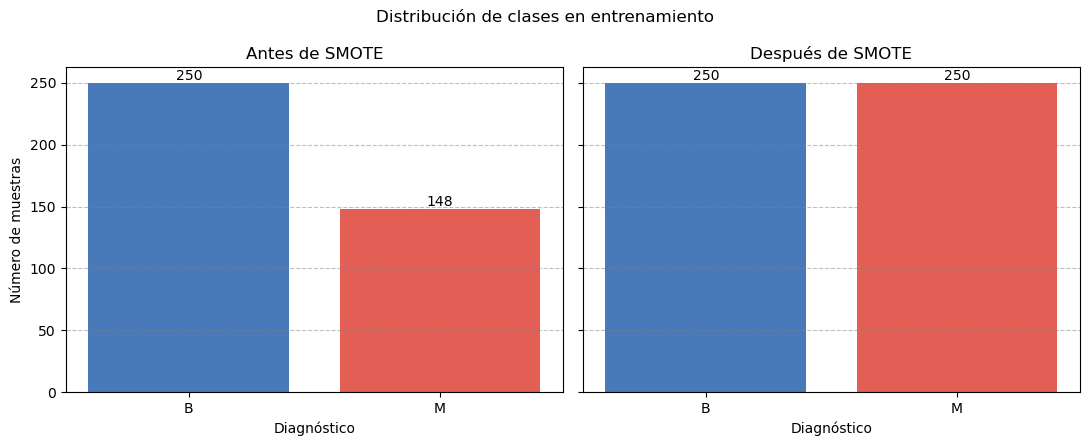

In [51]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize = (11, 4.5), sharey = True)

for ax, conteo, titulo in zip(axes, [antes, despues], ['Antes de SMOTE', 'Después de SMOTE']):

    barras = ax.bar(conteo.index, conteo.values, color = [AZUL_TELCEL, ROJO_TECOLOTE], alpha = 0.75)
    ax.set_title(titulo)
    ax.set_xlabel('Diagnóstico')
    ax.grid(axis = 'y', linestyle = '--', color = 'gray', alpha = 0.5)

    for b, v in zip(barras, conteo.values):

        ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha = 'center', va = 'bottom')

axes[0].set_ylabel('Número de muestras')
plt.suptitle('Distribución de clases en entrenamiento')
plt.tight_layout()
guardar_figura('02_distribucion_smote_cancer.png')
plt.show()

## 3. Reducción de dimensiones por PCA

### 3a) Aplicar PCA a datos balanceados

Se ocupará PCA con `mle`, es decir: Minka's Maximum Likelihood Estimation. Lo que hace esta cosa es inferir la dimensión estadísticamente más plausible.

In [52]:
pesea_mle = PCA(n_components = 'mle', 
            svd_solver = 'full', 
            iterated_power = 'auto',
            n_oversamples = 10,
            power_iteration_normalizer = 'auto',
            random_state = 43)
pesea_mle

,n_components,'mle'
,copy,True
,whiten,False
,svd_solver,'full'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,43


In [53]:
X_pesea_mle = pesea_mle.fit_transform(X_train)
print('Componentes seleccionados por MLE:', pesea_mle.n_components_)

Componentes seleccionados por MLE: 29


In [54]:
pesea_2d = PCA(n_components = 2, random_state = 43)
pesea_2d

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,43


In [55]:
X_pesea_2d = pesea_2d.fit_transform(X_train)

### 3b) Varianza acumulada 

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/03_varianza_acumulada_pesea_mle.png


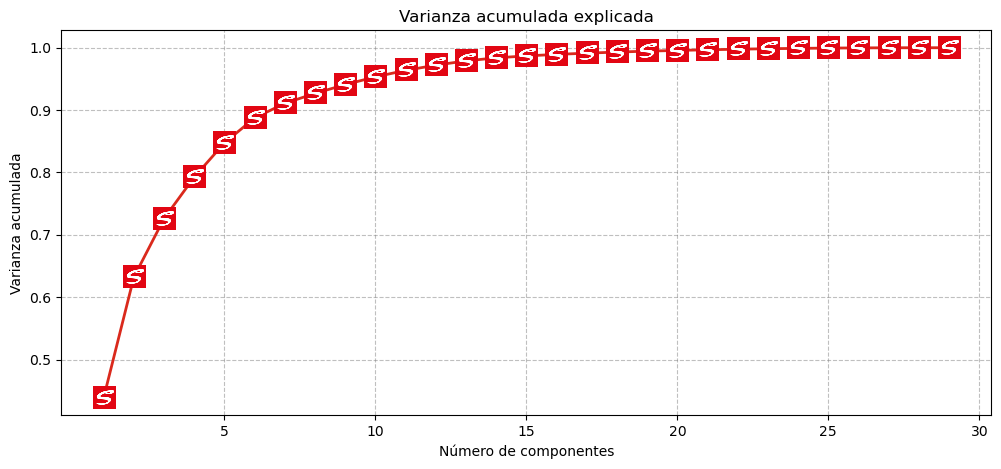

In [56]:
var_ac_mle = np.cumsum(pesea_mle.explained_variance_ratio_)

img = np.array(Image.open(RUTA_SANBORNS).convert('RGBA').resize((80, 80)))

plt.figure(figsize = (12, 5))

plt.plot(range(1, len(var_ac_mle) + 1), var_ac_mle, color = ROJO_TECOLOTE, linewidth = 2)

ax = plt.gca()

for x, y in zip(range(1, len(var_ac_mle) + 1), var_ac_mle):

    oi = OffsetImage(img, zoom = 0.2)
    ab = AnnotationBbox(oi, (x, y), frameon = False)
    ax.add_artist(ab)

plt.xlabel('Número de componentes')
plt.xticks([5, 10, 15, 20, 25, 30])
plt.ylabel('Varianza acumulada')
plt.title('Varianza acumulada explicada')

plt.grid(linestyle = '--', color = 'gray', alpha = 0.5)

guardar_figura('03_varianza_acumulada_pesea_mle.png')

plt.show()

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/04_varianza_acumulada_pesea_2d.png


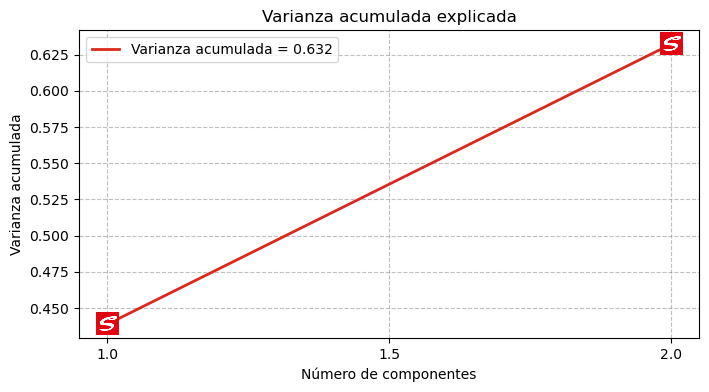

In [57]:
var_ac_2d = np.cumsum(pesea_2d.explained_variance_ratio_)

plt.figure(figsize = (8, 4))

plt.plot(range(1, len(var_ac_2d) + 1), var_ac_2d, color = ROJO_TECOLOTE, linewidth = 2)

ax = plt.gca()

for x, y in zip(range(1, len(var_ac_2d) + 1), var_ac_2d):

    oi = OffsetImage(img, zoom = 0.2)
    ab = AnnotationBbox(oi, (x, y), frameon = False)
    ax.add_artist(ab)
plt.xlabel('Número de componentes')
plt.xticks([1, 1.5, 2])
plt.ylabel('Varianza acumulada')
plt.legend(['Varianza acumulada = {}'.format(var_ac_2d[-1].round(3))])
plt.title('Varianza acumulada explicada')

plt.grid(linestyle = '--', color = 'gray', alpha = 0.5)

guardar_figura('04_varianza_acumulada_pesea_2d.png')

plt.show()

### 3c) Componentes para el 95% de varianza

In [58]:
pesea_var_95 = PCA(n_components = 0.95, random_state = 43)
pesea_var_95

,n_components,0.95
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,43


In [59]:
X_pesea_var_95 = pesea_var_95.fit_transform(X_train)
print(pesea_var_95.n_components_)

10


/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/04_varianza_acumulada_pesea_var_95.png


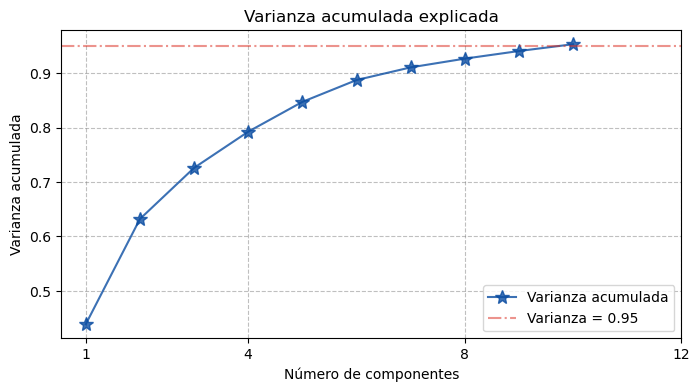

In [60]:
var_ac95 = np.cumsum(pesea_var_95.explained_variance_ratio_)

plt.figure(figsize = (8, 4))

plt.plot(range(1, len(var_ac95) + 1), var_ac95, marker = '*', markersize = 10, color = AZUL_TELCEL, alpha = 0.8)
plt.axhline(y = 0.95, linestyle = '-.', alpha = 0.5, color = ROJO_TECOLOTE)
plt.xlabel('Número de componentes')
plt.xticks([1, 4, 8, 12])
plt.ylabel('Varianza acumulada')
plt.title('Varianza acumulada explicada')
plt.legend(labels = ['Varianza acumulada', 'Varianza = 0.95'])
plt.grid(linestyle = '--', color = 'gray', alpha = 0.5)
guardar_figura('04_varianza_acumulada_pesea_var_95.png')
plt.show()

### 3d) Visualización de componentes principales y varianza acumulada

Empezemos con el intento de tener dos componentes:

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/05_pca_2d.png


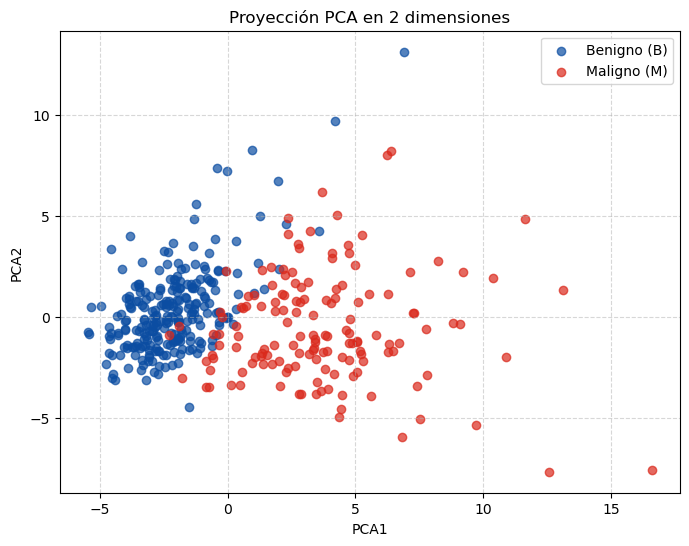

In [61]:
fig = plt.figure(figsize = (8, 6))
plt.scatter(X_pesea_2d[y_train == 'B', 0], X_pesea_2d[y_train == 'B', 1], color = AZUL_TELCEL, alpha = 0.7, label = 'Benigno (B)')
plt.scatter(X_pesea_2d[y_train == 'M', 0], X_pesea_2d[y_train == 'M', 1], color = ROJO_TECOLOTE, alpha = 0.7, label = 'Maligno (M)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Proyección PCA en 2 dimensiones')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
guardar_figura('05_pca_2d.png')
plt.show()

Seguimos con el 95% de varianza:

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/05_pca_var_95.png


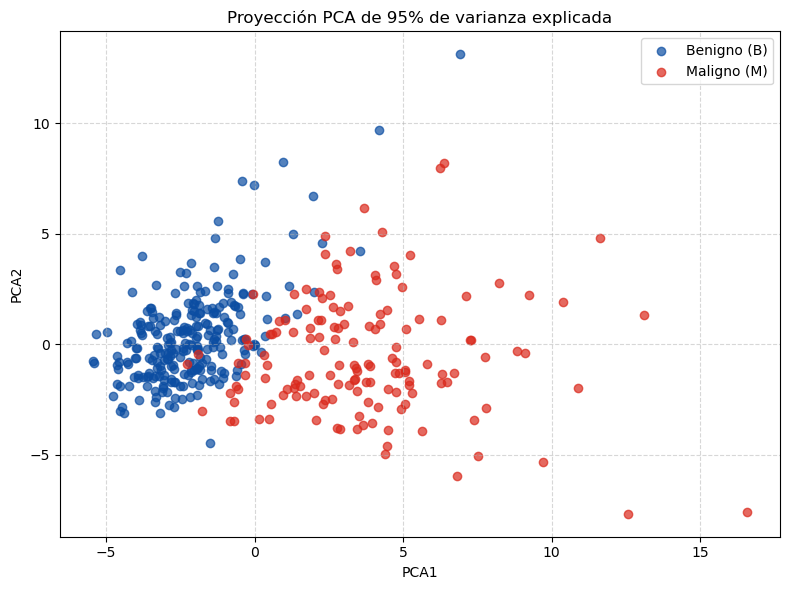

In [62]:
fig = plt.figure(figsize = (8, 6))
plt.scatter(X_pesea_var_95[y_train == 'B', 0], X_pesea_var_95[y_train == 'B', 1], 
            color = AZUL_TELCEL, alpha = 0.7, label = 'Benigno (B)')

plt.scatter(X_pesea_var_95[y_train == 'M', 0], X_pesea_var_95[y_train == 'M', 1], 
            color = ROJO_TECOLOTE, alpha = 0.7, label = 'Maligno (M)')

plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Proyección PCA de 95% de varianza explicada')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
guardar_figura('05_pca_var_95.png')
plt.tight_layout()
plt.show()


/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/05_pca_10_componentes.png


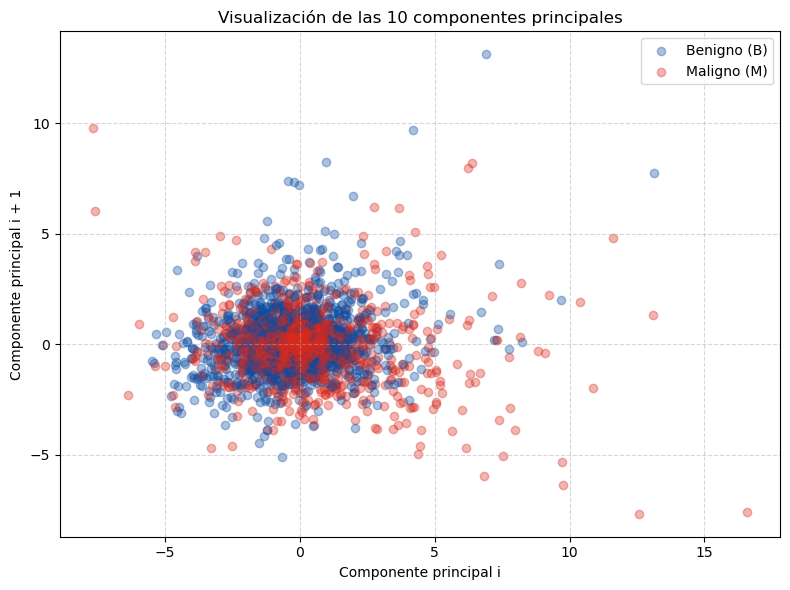

In [63]:
fig = plt.figure(figsize = (8, 6))

for i in range(1, pesea_var_95.n_components_):

    plt.scatter(X_pesea_var_95[y_train == 'B', i - 1], X_pesea_var_95[y_train == 'B', i], 
        color = AZUL_TELCEL, alpha = 0.35)

    plt.scatter(X_pesea_var_95[y_train == 'M', i - 1], X_pesea_var_95[y_train == 'M', i], 
                color = ROJO_TECOLOTE, alpha = 0.35)

plt.xlabel('Componente principal i')
plt.ylabel('Componente principal i + 1')
plt.title(f'Visualización de las {pesea_var_95.n_components_} componentes principales')
plt.legend(['Benigno (B)', 'Maligno (M)'])
plt.grid(linestyle = '--', alpha = 0.5)
plt.tight_layout()
guardar_figura('05_pca_10_componentes.png')
plt.show()

## 4. Definición de modelos y grid search

### 4a) Desarrollar pipelines que integren el preprocesamiento y el clasificador.

In [64]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_train_smote = le.transform(y_train_smote)
y_test = le.transform(y_test)

print(f'Clases codificadas: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Clases codificadas: {'B': np.int64(0), 'M': np.int64(1)}


In [65]:
# Pipelines (el escalado ya está hecho; integramos el clasificador en el pipeline)
pipe_knn = Pipeline([('clf', KNeighborsClassifier())])
pipe_dt  = Pipeline([('clf', DecisionTreeClassifier(random_state = 43))])
pipe_svm = Pipeline([('clf', SVC(random_state = 43))])

# Cuadros de hiperparámetros (siguiendo el PDF)
param_knn = {
    'clf__n_neighbors': [1, 3, 5, 7, 9],
    'clf__weights': ['uniform', 'distance'],
    'clf__metric': ['euclidean', 'manhattan'],
}

param_dt = {
    'clf__max_depth': [3, 5, 7, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__criterion': ['gini', 'entropy'],
}

param_svm = {
    'clf__kernel': ['linear', 'rbf'],
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 'auto', 0.01, 0.1],
}

# Diccionario de modelos para iterar
modelos = {
    'KNN': (pipe_knn, param_knn),
    'Árbol de Decisión': (pipe_dt, param_dt),
    'SVM': (pipe_svm, param_svm),
}

### 4b) Grid Search

In [66]:
# Grid search con CV de 5 folds optimizando accuracy
resultados = {}

for nombre, (pipe, grid) in modelos.items():

    gs = GridSearchCV(pipe, grid, cv = 5, scoring = 'accuracy', n_jobs = -1)
    gs.fit(X_train_smote, y_train_smote)
    resultados[nombre] = gs
    print(f'Mejores parámetros: {gs.best_params_}')
    print(f'Mejor CV accuracy: {gs.best_score_:.4f}\n')

Mejores parámetros: {'clf__metric': 'euclidean', 'clf__n_neighbors': 9, 'clf__weights': 'distance'}
Mejor CV accuracy: 0.9860

Mejores parámetros: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_split': 5}
Mejor CV accuracy: 0.9500

Mejores parámetros: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Mejor CV accuracy: 0.9740



In [67]:
metricas = []

for nombre, gs in resultados.items():

    y_pred = gs.predict(X_test)
    metricas.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label = 1),
        'Recall': recall_score(y_test, y_pred, pos_label = 1),
        'F1': f1_score(y_test, y_pred, pos_label = 1)
    })

df_metricas = pd.DataFrame(metricas).set_index('Modelo').round(4)
df_metricas

,Accuracy,Precision,Recall,F1
Modelo,,,,
KNN,0.9532,0.9118,0.9688,0.9394
Árbol de Decisión,0.9474,0.9231,0.9375,0.9302
SVM,0.9766,0.9545,0.9844,0.9692


/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/06_matrices_confusion_cancer.png


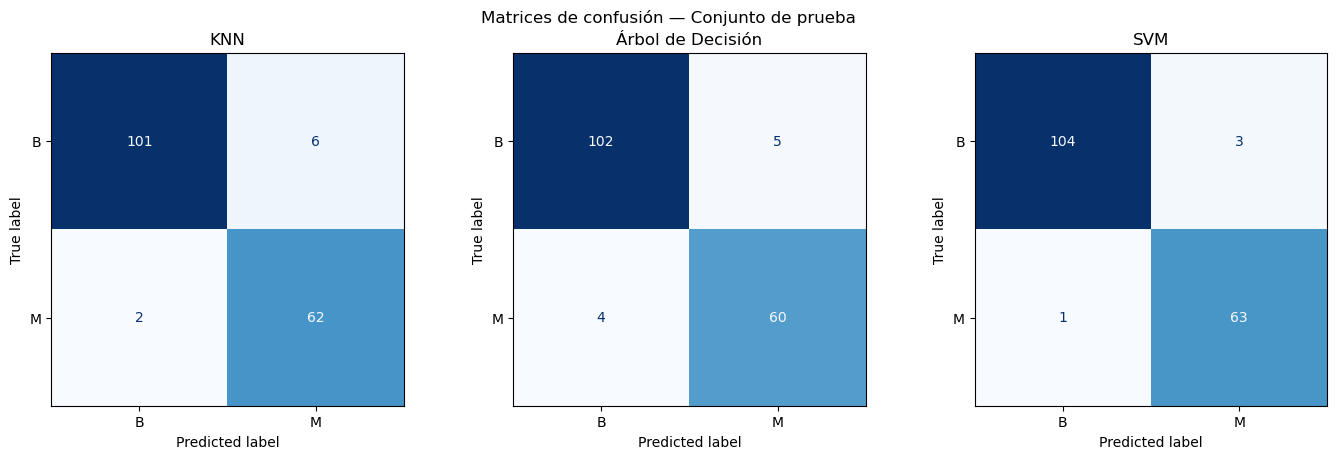

In [68]:
fig, axes = plt.subplots(1, 3, figsize = (14, 4.5))

for ax, (nombre, gs) in zip(axes, resultados.items()):
    y_pred = gs.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels = [0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels = ['B', 'M'])
    disp.plot(ax = ax, cmap = 'Blues', colorbar = False)
    ax.set_title(nombre)
    ax.grid(False)

plt.suptitle('Matrices de confusión — Conjunto de prueba')
plt.tight_layout()
guardar_figura('06_matrices_confusion_cancer.png')
plt.show()

## 5. Configuración de modelos e hiperparámetros


### 5a-c) Modelos knn, árboles de decisión, SVM

Variable        Shape      Únicos
───────────────────────────────────
X_train_2d      (500, 2)   [0 1]
y_train_smote   (500,)     [0 1]
X_test_2d       (171, 2)   [0 1]
y_test          (171,)     [0 1]
/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/07a_frontera_knn.png


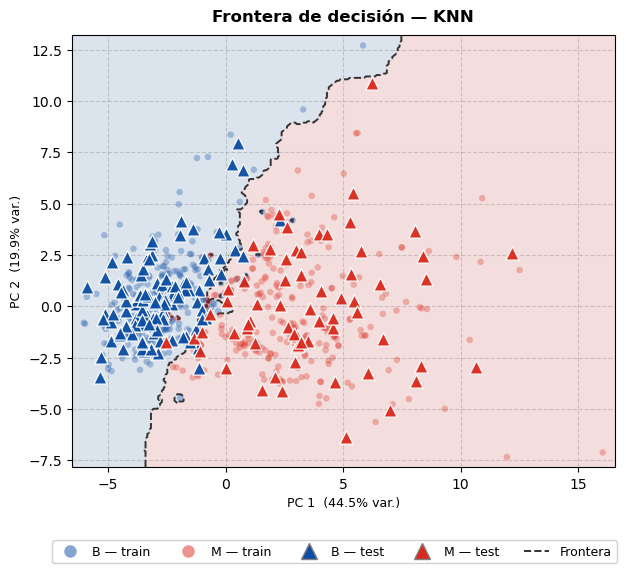

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/07b_frontera_arbol.png


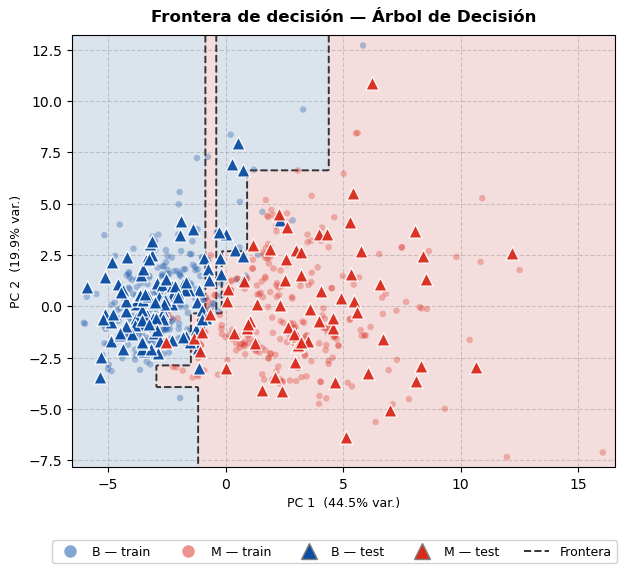

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/07c_frontera_svm.png


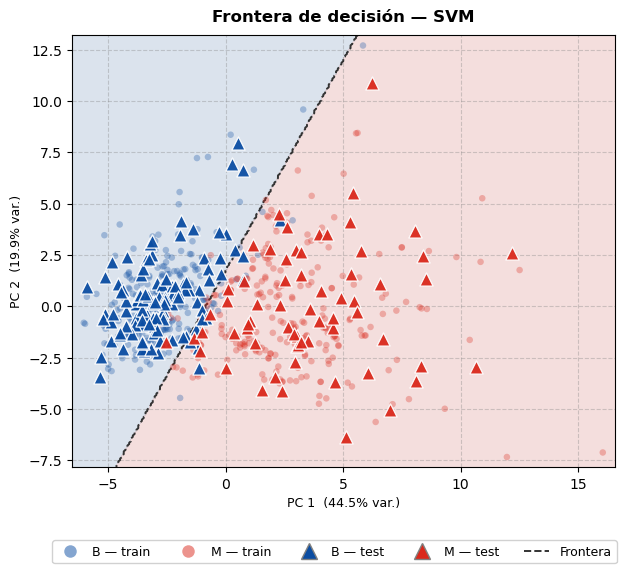

In [69]:
# PCA 2D sobre los datos balanceados de entrenamiento
pesea_2d_bal = PCA(n_components = 2, random_state = 43)
X_train_2d   = pesea_2d_bal.fit_transform(X_train_smote)
X_test_2d    = pesea_2d_bal.transform(X_test)

y_train_bal_arr = np.asarray(y_train_smote).ravel()
y_test_arr      = np.asarray(y_test).ravel()

# Diagnóstico
print(f"{'Variable':<15} {'Shape':<10} Únicos")
print('─' * 35)
print(f"{'X_train_2d':<15} {str(X_train_2d.shape):<10} {np.unique(y_train_bal_arr)}")
print(f"{'y_train_smote':<15} {str(y_train_bal_arr.shape):<10} {np.unique(y_train_bal_arr)}")
print(f"{'X_test_2d':<15} {str(X_test_2d.shape):<10} {np.unique(y_test_arr)}")
print(f"{'y_test':<15} {str(y_test_arr.shape):<10} {np.unique(y_test_arr)}")

# Malla
margen = 0.5
x_min, x_max = X_train_2d[:, 0].min() - margen, X_train_2d[:, 0].max() + margen
y_min, y_max = X_train_2d[:, 1].min() - margen, X_train_2d[:, 1].max() + margen
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

var_pc1 = pesea_2d_bal.explained_variance_ratio_[0] * 100
var_pc2 = pesea_2d_bal.explained_variance_ratio_[1] * 100

leyenda = [
    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = AZUL_TELCEL,
           markersize = 9, markeredgecolor = 'none', alpha = 0.5, label = 'B — train'),
    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = ROJO_TECOLOTE,
           markersize = 9, markeredgecolor = 'none', alpha = 0.5, label = 'M — train'),
    Line2D([0], [0], marker = '^', color = 'w', markerfacecolor = AZUL_TELCEL,
           markersize = 11, markeredgecolor = 'gray', label = 'B — test'),
    Line2D([0], [0], marker = '^', color = 'w', markerfacecolor = ROJO_TECOLOTE,
           markersize = 11, markeredgecolor = 'gray', label = 'M — test'),
    Line2D([0], [0], color = '#333333', linewidth = 1.4, linestyle = '--', label = 'Frontera'),
]

nombres_archivo = {
    'KNN': '07a_frontera_knn.png',
    'Árbol de Decisión': '07b_frontera_arbol.png',
    'SVM': '07c_frontera_svm.png',
}

for nombre, gs in resultados.items():
    clf_2d = clone(gs.best_estimator_.named_steps['clf'])
    clf_2d.fit(X_train_2d, y_train_bal_arr)

    Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    fig, ax = plt.subplots(figsize = (7, 6))
    fig.subplots_adjust(bottom = 0.18, top = 0.90)

    # Región de decisión
    ax.contourf(xx, yy, Z, levels = [-0.5, 0.5, 1.5],
                colors = [AZUL_TELCEL, ROJO_TECOLOTE], alpha = 0.12, zorder = 1)
    # Línea de frontera
    ax.contour(xx, yy, Z,
               levels = [0.5], colors = ['#333333'], linewidths = 1.4,
               linestyles = '--', zorder = 2)

    # Entrenamiento — círculos semitransparentes, sin borde
    for cls, color in [(0, AZUL_TELCEL), (1, ROJO_TECOLOTE)]:
        mask = y_train_bal_arr == cls
        ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                   color = color, alpha = 0.30, s = 22, marker = 'o', edgecolors = 'none', zorder = 3)

    # Prueba — triángulos opacos con borde blanco para destacar
    for cls, color in [(0, AZUL_TELCEL), (1, ROJO_TECOLOTE)]:
        mask = y_test_arr == cls
        ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1], color = color, alpha = 0.95, 
        s = 90, marker = '^',  edgecolors = 'white', linewidths = 0.9, zorder = 4)

    ax.set_title(f'Frontera de decisión — {nombre}', fontsize = 12, fontweight = 'bold', pad = 10)
    ax.set_xlabel(f'PC 1  ({var_pc1:.1f}% var.)', fontsize = 9)
    ax.set_ylabel(f'PC 2  ({var_pc2:.1f}% var.)', fontsize = 9)
    ax.set_facecolor('#f8f8f8')
    ax.grid(linestyle = '--', alpha = 0.35, color = 'gray')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    fig.legend(handles = leyenda, loc = 'lower center', ncol = 5, bbox_to_anchor = (0.5, 0.01), 
    fontsize = 9, framealpha = 0.9)

    guardar_figura(nombres_archivo[nombre])
    plt.show()

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/08_arbol_decision_cancer.png


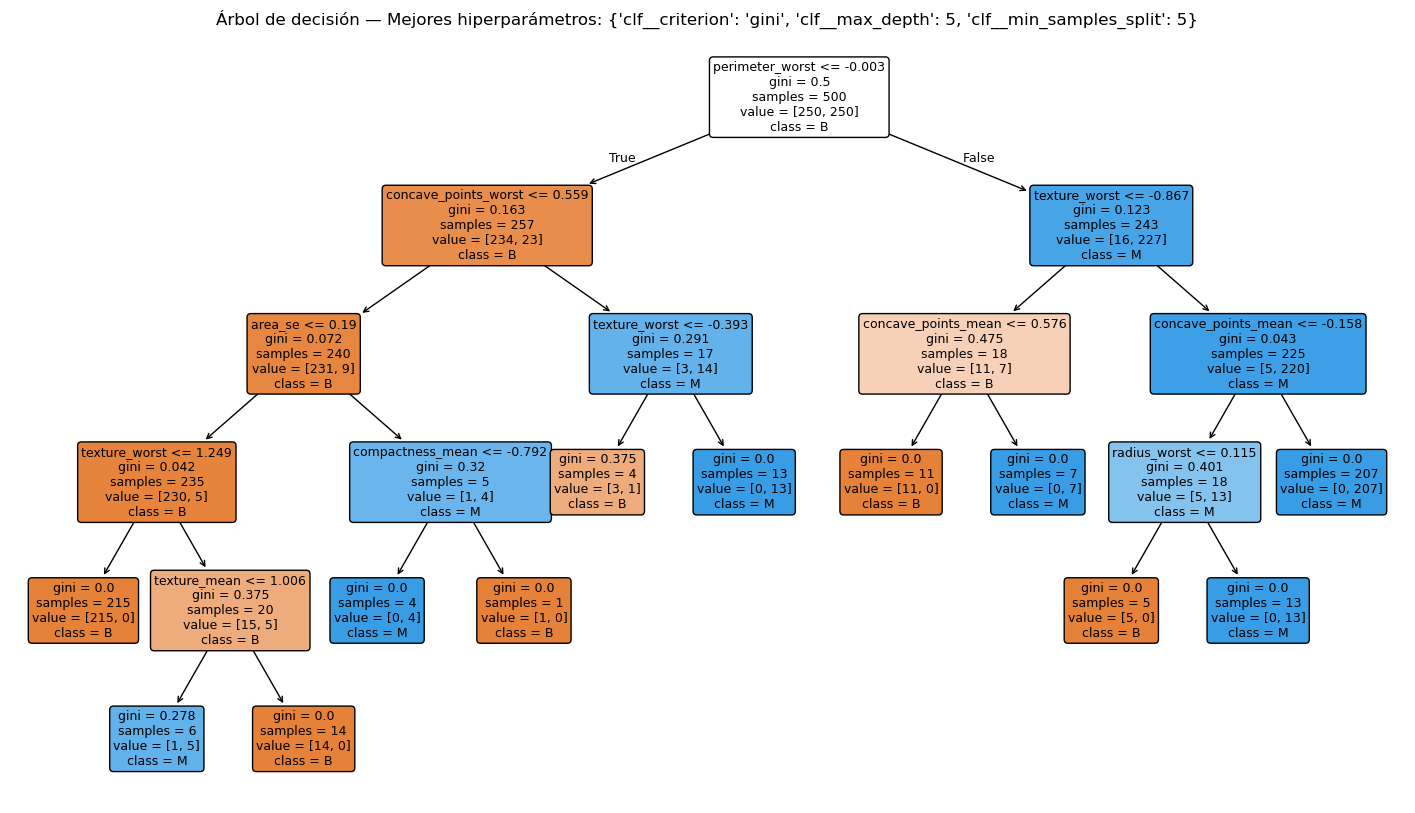

In [70]:
mejor_arbol  = resultados['Árbol de Decisión'].best_estimator_.named_steps['clf']
mejor_params = resultados['Árbol de Decisión'].best_params_

plt.figure(figsize = (18, 10))
plot_tree(mejor_arbol,
          feature_names = list(columnas_num),
          class_names = ['B', 'M'],
          filled = True,
          rounded = True,
          fontsize = 9)
plt.title(f'Árbol de decisión — Mejores hiperparámetros: {mejor_params}')
guardar_figura('08_arbol_decision_cancer.png')
plt.show()

## 6. Entrenamiento, evaluación y comparación

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P4/Reporte/Img/09_comparacion_exactitud_cancer.png


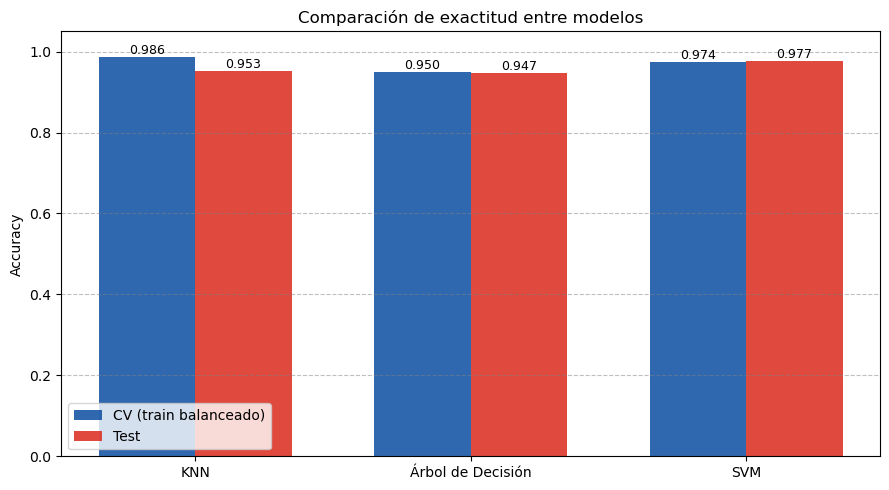

In [71]:
modelos_nom = list(resultados.keys())
acc_cv   = [resultados[m].best_score_ for m in modelos_nom]
acc_test = [accuracy_score(y_test, resultados[m].predict(X_test)) for m in modelos_nom]

fig, ax = plt.subplots(figsize = (9, 5))

x = np.arange(len(modelos_nom))
ancho = 0.35

barras1 = ax.bar(x - ancho/2, acc_cv,   ancho, label = 'CV (train balanceado)',
                 color = AZUL_TELCEL, alpha = 0.85)
barras2 = ax.bar(x + ancho/2, acc_test, ancho, label = 'Test',
                 color = ROJO_TECOLOTE, alpha = 0.85)

for barras in (barras1, barras2):
    for b in barras:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                f'{b.get_height():.3f}', ha = 'center', va = 'bottom', fontsize = 9)

ax.set_xticks(x)
ax.set_xticklabels(modelos_nom)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Comparación de exactitud entre modelos')
ax.legend()
ax.grid(axis = 'y', linestyle = '--', color = 'gray', alpha = 0.5)
plt.tight_layout()
guardar_figura('09_comparacion_exactitud_cancer.png')
plt.show()

In [72]:
print('Hiperparámetro más relevante por modelo')

for nombre, gs in resultados.items():

    cv_df = pd.DataFrame(gs.cv_results_)
    params_cols = [c for c in cv_df.columns if c.startswith('param_clf__')]

    rangos = {}

    for p in params_cols:

        agg = cv_df.groupby(p, dropna = False)['mean_test_score'].mean()
        rangos[p.replace('param_clf__', '')] = agg.max() - agg.min()

    rangos_df = pd.Series(rangos).sort_values(ascending = False)
    print(f'\n{nombre}')
    print(rangos_df.round(4).to_string())
    print(f'Más relevante: {rangos_df.index[0]} '
          f'(Dif accuracy = {rangos_df.iloc[0]:.4f})')

Hiperparámetro más relevante por modelo

KNN
weights        0.0110
n_neighbors    0.0040
metric         0.0002
Más relevante: weights (Dif accuracy = 0.0110)

Árbol de Decisión
criterion            0.0112
max_depth            0.0037
min_samples_split    0.0000
Más relevante: criterion (Dif accuracy = 0.0112)

SVM
C         0.0152
kernel    0.0120
gamma     0.0063
Más relevante: C (Dif accuracy = 0.0152)
